# Part 4 — Representational Geometry: Dimensionality of the Shared Attractor

Tests whether the consistency peak coincides with a collapse in the effective
dimensionality of the shared representation, using participation ratio (PR) as
the dimensionality measure. Characterises the structure of the peak-window
attractor via eigendecomposition of the average similarity matrix.

**Depends on:** `responses.h5`, `manifest.json`, `part3_outputs.npz`,
                `part1_outputs.npz`, `image_templates.npy`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]   # default single-series consistency curve
COL_FIT  = colors["COL_FIT"]    # model fits / peak annotations
COL_REF  = colors["COL_REF"]    # reference lines / baselines
COL_DIM  = colors["COL_DIM"]    # dimensionality / participation ratio (own quantity)

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES    = manifest['n_images']
SESSION_IDS = manifest['selected_session_ids_visp']

# Part 3 outputs — temporal profile reference
p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms          = p3['times_ms'].tolist()   # list: needed for .index() calls below
mean_c            = p3['mean_c']
window_centers_ms = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS   = float(p3['window_width_ms'])
peak_t            = float(p3['peak_t'])
peak_c_val        = float(p3['peak_c'])
SLIDE_START_MS    = int(min(times_ms))
SLIDE_END_MS      = int(max(times_ms)) + 1

# Part 1 outputs — per-image consistency and image properties (used in 4.2)
p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
consistency    = p1['consistency']      # (118,)
mean_sparsity  = p1['mean_sparsity']   # (118,)
mean_magnitude = p1['mean_magnitude']  # (118,)
sort_idx_p1    = p1['sort_idx']        # (118,)

# Image display templates (gallery in S6)
natural_scenes = np.load(ARCHIVE_DIR / 'image_templates.npy')   # (118, 256, 256) uint8

# CNN embeddings — all layers needed for eigenvector property heatmap in 4.2
_cnn       = np.load(ARCHIVE_DIR / 'cnn_embeddings.npz')
layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'final']
layer_emb   = {name: _cnn[name] for name in layer_names}

print(f'Sessions: {len(SESSION_IDS)}, Images: {N_IMAGES}')
print(f'Sliding windows: {len(window_centers_ms)}, peak at {peak_t:.0f} ms')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Sessions: 32, Images: 118
Sliding windows: 43, peak at 100 ms


In [3]:
def participation_ratio(sim_matrix: np.ndarray) -> float:
    """
    Effective dimensionality of a similarity matrix.
    PR = (Σ λ_i)² / Σ λ_i²  where λ_i are the positive eigenvalues.
    """
    eigvals = np.linalg.eigvalsh(sim_matrix)
    eigvals = eigvals[eigvals > 0]
    return float(eigvals.sum() ** 2 / (eigvals ** 2).sum())

In [4]:
print('Loading VISp tensors...')
all_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        all_tensors[sid] = grp['tensor'][:]   # (118, n_units, 95)
print(f'Loaded {len(all_tensors)} sessions.')

Loading VISp tensors...


Loaded 32 sessions.


## 4.1 — Participation ratio over time

PR is computed on the *average* cosine-similarity matrix across mice at each
window. Averaging first, then computing PR, measures the dimensionality of the
*shared* representational geometry — the part all mice agree on — rather than
the dimensionality of any individual mouse's representation.

The PR of the average matrix is tracked alongside the per-mouse mean PR
(mean of individual-session PRs) as a cross-check.

In [5]:
# Subsample to every other step (20 ms resolution) to halve compute.
PR_TIMES = times_ms[::2]

pr_results = {}

for t_ms in PR_TIMES:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2
    sim_sum    = np.zeros((N_IMAGES, N_IMAGES), dtype=np.float64)
    pr_per_mouse = []

    for sid in SESSION_IDS:
        X    = window_response(all_tensors[sid], t_lo, t_hi)
        norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        sim  = (norm @ norm.T).astype(np.float64)
        sim_sum += sim
        pr_per_mouse.append(participation_ratio(sim))

    n_mice      = len(SESSION_IDS)
    avg_sim     = sim_sum / n_mice
    pr_avg      = participation_ratio(avg_sim)
    pr_pmm_mean = np.mean(pr_per_mouse)
    pr_pmm_sem  = np.std(pr_per_mouse) / np.sqrt(n_mice)
    pr_results[t_ms] = {
        'pr_avg':     pr_avg,
        'pr_pmm':     pr_pmm_mean,
        'pr_pmm_sem': pr_pmm_sem,
    }
    print(f't = {t_ms:+4d} ms : PR(avg sim) = {pr_avg:.2f},  '
          f'PR(per-mouse) = {pr_pmm_mean:.2f} ± {pr_pmm_sem:.2f}')

times_pr  = sorted(pr_results.keys())
pr_avg_ts = np.array([pr_results[t]['pr_avg']     for t in times_pr])
pr_pmm_ts = np.array([pr_results[t]['pr_pmm']     for t in times_pr])
pr_sem_ts = np.array([pr_results[t]['pr_pmm_sem'] for t in times_pr])

pre_pr  = np.mean([pr_results[t]['pr_avg'] for t in times_pr if t < 0])
pre_pr_pmm = np.mean([pr_results[t]['pr_pmm'] for t in times_pr if t < 0])
peak_pr = pr_results[min(times_pr, key=lambda t: abs(t - peak_t))]['pr_avg']
sus_pr  = pr_results[min(times_pr, key=lambda t: abs(t - 250))]['pr_avg']

# Snap consistency curve to PR time points for the correlation test
times_pr_snap = [min(times_ms, key=lambda t: abs(t - tp)) for tp in times_pr]
mean_c_snap   = np.array([mean_c[times_ms.index(t)] for t in times_pr_snap])
post_pr_mask  = np.array(times_pr) >= 0

# PR of the averaged-matrix (partly definitional with consistency, since both
# are computed from the same cross-mouse-averaged similarity structure).
r_pr_cons, p_pr_cons = spearmanr(mean_c_snap[post_pr_mask], pr_avg_ts[post_pr_mask])

# PR averaged per-mouse (each mouse's own PR, then averaged) — not confounded
# with cross-mouse agreement the way the averaged-matrix PR is, since it never
# involves averaging similarity matrices across mice.
r_pr_pmm, p_pr_pmm = spearmanr(mean_c_snap[post_pr_mask], pr_pmm_ts[post_pr_mask])

print(f'\nPR pre-stimulus (avg-matrix) : {pre_pr:.2f}')
print(f'PR pre-stimulus (per-mouse)  : {pre_pr_pmm:.2f}')
print(f'PR at peak ({peak_t} ms): {peak_pr:.2f}')
print(f'PR at 250 ms      : {sus_pr:.2f}')
print(f'Post-stim Spearman r(consistency, PR avg-matrix) = {r_pr_cons:.3f},  p = {p_pr_cons:.2e}')
print(f'Post-stim Spearman r(consistency, PR per-mouse)  = {r_pr_pmm:.3f},  p = {p_pr_pmm:.2e}')

t =  -50 ms : PR(avg sim) = 108.07,  PR(per-mouse) = 35.77 ± 1.77
t =  -30 ms : PR(avg sim) = 107.96,  PR(per-mouse) = 35.58 ± 1.79
t =  -10 ms : PR(avg sim) = 107.97,  PR(per-mouse) = 35.47 ± 1.78


t =  +10 ms : PR(avg sim) = 107.54,  PR(per-mouse) = 35.26 ± 1.74
t =  +30 ms : PR(avg sim) = 107.44,  PR(per-mouse) = 35.39 ± 1.72


t =  +50 ms : PR(avg sim) = 83.10,  PR(per-mouse) = 30.65 ± 1.43
t =  +70 ms : PR(avg sim) = 52.22,  PR(per-mouse) = 21.27 ± 0.97


t =  +90 ms : PR(avg sim) = 31.49,  PR(per-mouse) = 15.25 ± 0.78
t = +110 ms : PR(avg sim) = 31.36,  PR(per-mouse) = 15.54 ± 0.87


t = +130 ms : PR(avg sim) = 38.21,  PR(per-mouse) = 18.21 ± 0.97
t = +150 ms : PR(avg sim) = 46.79,  PR(per-mouse) = 21.15 ± 1.03


t = +170 ms : PR(avg sim) = 52.64,  PR(per-mouse) = 22.63 ± 1.03
t = +190 ms : PR(avg sim) = 56.09,  PR(per-mouse) = 23.42 ± 1.11


t = +210 ms : PR(avg sim) = 58.93,  PR(per-mouse) = 24.13 ± 1.17
t = +230 ms : PR(avg sim) = 61.11,  PR(per-mouse) = 24.52 ± 1.19


t = +250 ms : PR(avg sim) = 61.18,  PR(per-mouse) = 24.40 ± 1.19
t = +270 ms : PR(avg sim) = 61.10,  PR(per-mouse) = 24.23 ± 1.18
t = +290 ms : PR(avg sim) = 60.70,  PR(per-mouse) = 24.48 ± 1.19


t = +310 ms : PR(avg sim) = 59.72,  PR(per-mouse) = 25.12 ± 1.19
t = +330 ms : PR(avg sim) = 42.47,  PR(per-mouse) = 17.90 ± 0.97


t = +350 ms : PR(avg sim) = 36.43,  PR(per-mouse) = 16.07 ± 1.04
t = +370 ms : PR(avg sim) = 45.47,  PR(per-mouse) = 19.45 ± 1.40

PR pre-stimulus (avg-matrix) : 108.00
PR pre-stimulus (per-mouse)  : 35.61
PR at peak (100.0 ms): 31.49
PR at 250 ms      : 61.18
Post-stim Spearman r(consistency, PR avg-matrix) = -0.853,  p = 3.54e-06
Post-stim Spearman r(consistency, PR per-mouse)  = -0.805,  p = 3.19e-05


## 4.2 — Eigenvector characterization of the peak-window attractor

Eigendecompose the average similarity matrix at the peak consistency window
(100 ms) to characterise the geometric structure of the shared representation.
The top eigenvectors reveal which dimensions of image space are most compressed
at the moment of peak cross-mouse agreement.

In [6]:
N_EIGVECS = 8

print(f'Computing average similarity matrix at {peak_t} ms...')
sim_sum_peak = np.zeros((N_IMAGES, N_IMAGES), dtype=np.float64)
n_peak = 0

for sid in SESSION_IDS:
    X    = window_response(all_tensors[sid],
                           peak_t - WINDOW_WIDTH_MS/2,
                           peak_t + WINDOW_WIDTH_MS/2)
    norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    sim_sum_peak += (norm @ norm.T).astype(np.float64)
    n_peak += 1

avg_sim_peak = sim_sum_peak / n_peak

eigvals, eigvecs = np.linalg.eigh(avg_sim_peak)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]   # descending order

total_var = eigvals[eigvals > 0].sum()
var_exp   = eigvals[:N_EIGVECS] / total_var * 100
cum_var   = np.cumsum(var_exp)
proj      = eigvecs[:, :N_EIGVECS]   # (118, 8) — image projections

print(f'\nTop {N_EIGVECS} eigenvectors:')
print(f'{"Dim":>4}  {"Var%":>6}  {"Cum%":>6}')
for i in range(N_EIGVECS):
    print(f'{i+1:>4}  {var_exp[i]:>6.2f}  {cum_var[i]:>6.2f}')

# Correlate eigenvector projections with image properties
image_props = {
    'Sparsity':  mean_sparsity,
    'Magnitude': mean_magnitude,
    'Consistency': consistency,
    **{f'CNN {k}': layer_emb[k].mean(axis=1) for k in layer_emb},
}
prop_names = list(image_props.keys())
n_props    = len(prop_names)

eigvec_r = np.zeros((n_props, N_EIGVECS))
eigvec_p = np.zeros((n_props, N_EIGVECS))
for j, (name, vals) in enumerate(image_props.items()):
    for k in range(N_EIGVECS):
        r, p = spearmanr(proj[:, k], vals)
        eigvec_r[j, k] = r
        eigvec_p[j, k] = p

print('\nSpearman r: eigenvector projections vs. image properties')
hdr = f'{"Property":>20}  ' + ''.join([f'  Dim{k+1}' for k in range(N_EIGVECS)])
print(hdr)
for j, name in enumerate(prop_names):
    row = ''.join([f'  {eigvec_r[j,k]:+.2f}{"*" if eigvec_p[j,k]<0.05 else " "}'
                   for k in range(N_EIGVECS)])
    print(f'{name:>20}  {row}')

Computing average similarity matrix at 100.0 ms...

Top 8 eigenvectors:
 Dim    Var%    Cum%
   1   14.75   14.75
   2    4.60   19.34
   3    3.57   22.91
   4    3.21   26.13
   5    2.77   28.90
   6    2.12   31.02
   7    2.07   33.09
   8    2.07   35.16

Spearman r: eigenvector projections vs. image properties
            Property    Dim1  Dim2  Dim3  Dim4  Dim5  Dim6  Dim7  Dim8
            Sparsity    -0.06   -0.51*  -0.10   +0.11   +0.23*  -0.03   -0.12   +0.24*
           Magnitude    +0.44*  +0.47*  +0.16   -0.11   -0.21*  +0.06   +0.15   -0.14 
         Consistency    -0.13   -0.03   -0.12   +0.06   -0.11   -0.19*  -0.11   -0.28*
          CNN layer1    +0.41*  -0.47*  +0.04   +0.15   +0.06   -0.16   -0.00   -0.02 
          CNN layer2    +0.40*  -0.19*  +0.13   +0.14   +0.12   -0.09   +0.01   +0.13 
          CNN layer3    +0.10   +0.22*  +0.13   -0.10   +0.06   +0.04   -0.04   +0.03 
          CNN layer4    -0.36*  -0.02   +0.15   +0.02   -0.09   +0.13   -0.10   -0.01 
 

---
## Figures

**Fig. 4** — The consistency peak coincides with collapse into a low-dimensional attractor.
**S5** — Eigenvector loadings on image properties (full heatmap).
**S6** — Attractor-space image gallery.


Fig. 4A — Participation ratio and cross-mouse consistency over time

--- times_ms ---
[-50 -30 -10  10  30  50  70  90 110 130 150 170 190 210 230 250 270 290
 310 330]
...[22 elements total]

--- mean_consistency ---
shape=(22,)
[ 0.000048 -0.000179 -0.000164  0.001345  0.002349  0.094116  0.19982   0.290623  0.305512  0.28484   0.253955  0.225004  0.205867  0.19355   0.182126  0.179258  0.178128  0.188539  0.19364
  0.204023]
...[22 elements total]

--- times_pr ---
[-50 -30 -10  10  30  50  70  90 110 130 150 170 190 210 230 250 270 290
 310 330]
...[22 elements total]

--- pr_avg_of_avg_sim ---
shape=(22,)
[108.070924 107.955162 107.965113 107.543378 107.439266  83.099028  52.22119   31.488435  31.358325  38.208775  46.791927  52.635478  56.09412   58.927341  61.109462  61.181718  61.100801  60.696487
  59.721496  42.474251]
...[22 elements total]

--- pr_per_mouse_mean ---
shape=(22,)
[35.774472 35.580453 35.4705   35.257335 35.388402 30.648126 21.266528 15.253662 15.541692 18.21

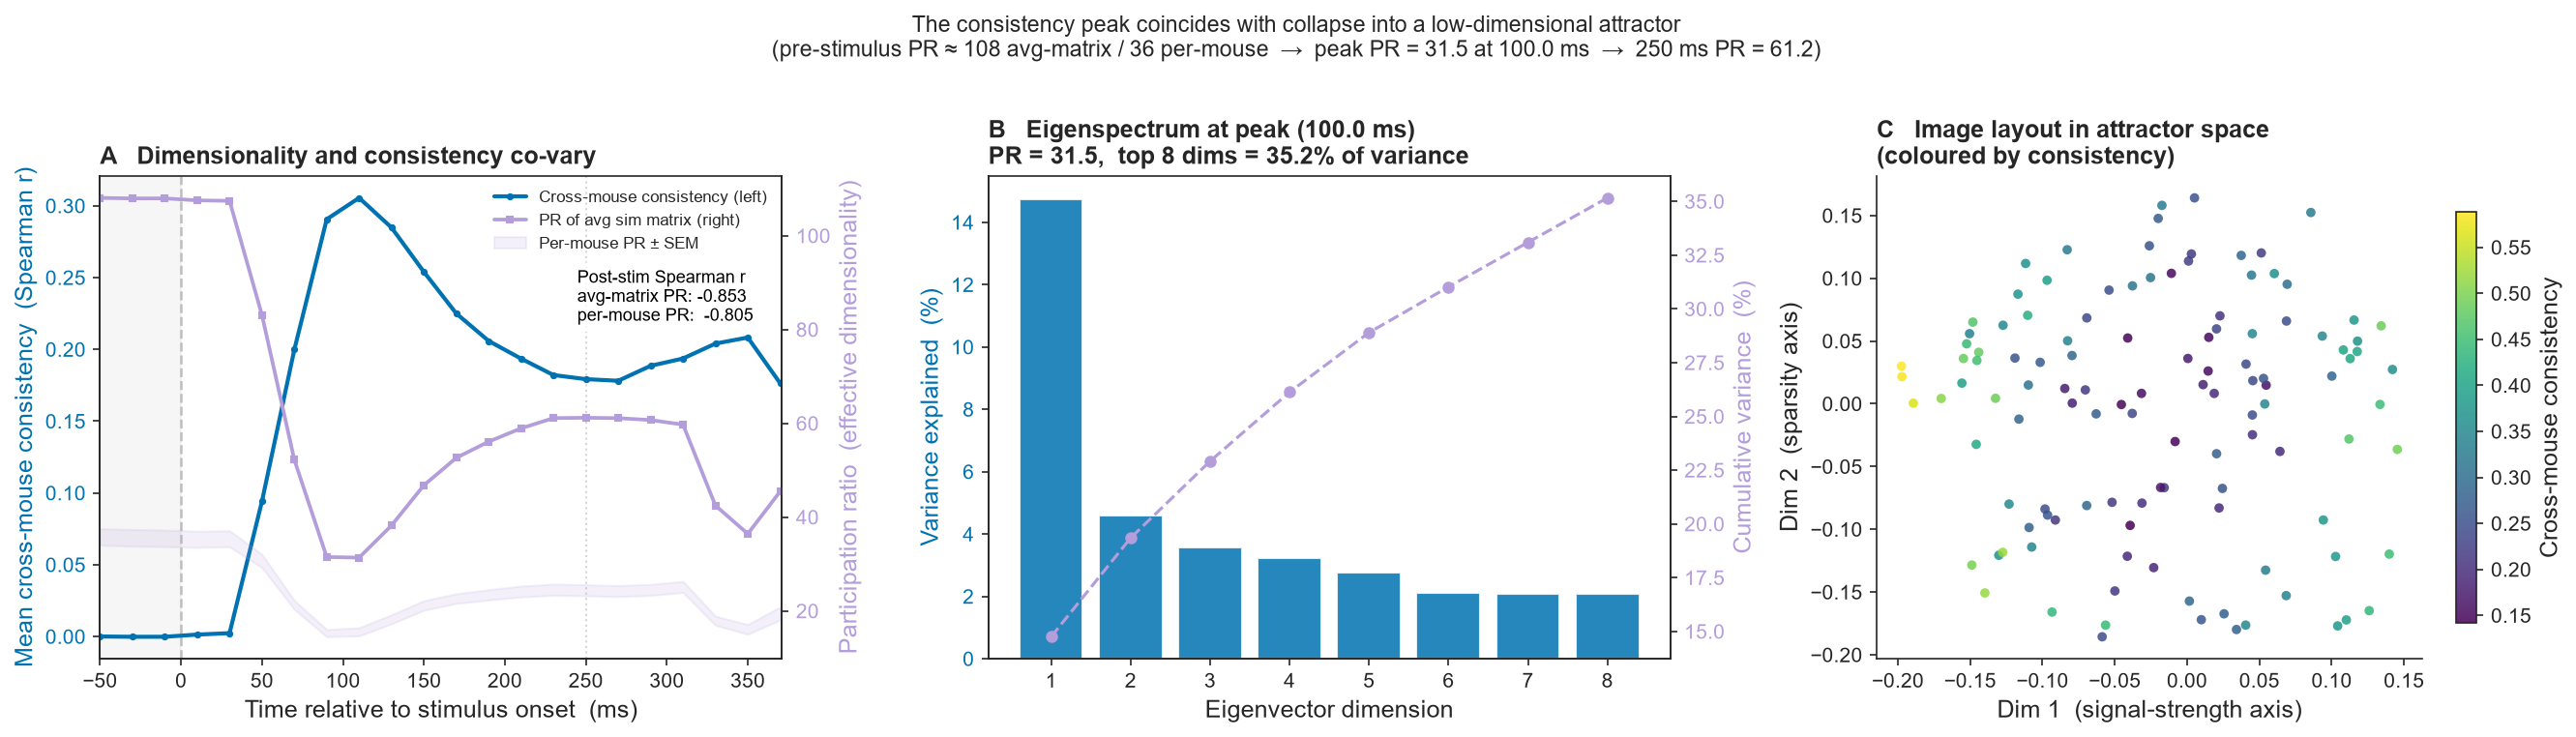

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: dual-axis PR and consistency over time
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
ax1.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax1.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.0, alpha=0.4)

ax1.plot(times_pr_snap, mean_c_snap, color=COL_DATA, linewidth=2.0,
         marker='o', markersize=2.5,
         label='Cross-mouse consistency (left)')
ax1.set_xlabel('Time relative to stimulus onset  (ms)')
ax1.set_ylabel('Mean cross-mouse consistency  (Spearman r)', color=COL_DATA)
ax1.tick_params(axis='y', labelcolor=COL_DATA)
ax1.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(50))

ax2.plot(times_pr, pr_avg_ts, color=COL_DIM, linewidth=1.8,
         marker='s', markersize=2.5, label='PR of avg sim matrix (right)')
ax2.fill_between(times_pr,
                 pr_pmm_ts - pr_sem_ts,
                 pr_pmm_ts + pr_sem_ts,
                 color=COL_DIM, alpha=0.15, label='Per-mouse PR ± SEM')
ax2.set_ylabel('Participation ratio  (effective dimensionality)', color=COL_DIM)
ax2.tick_params(axis='y', labelcolor=COL_DIM)

# Annotate both r values: averaged-matrix PR (partly definitional with
# consistency) and per-mouse PR (the less-confounded statistic, since it
# never averages similarity matrices across mice).
ax1.annotate(f'Post-stim Spearman r\n'
             f'avg-matrix PR: {r_pr_cons:.3f}\n'
             f'per-mouse PR:  {r_pr_pmm:.3f}',
             xy=(0.7, 0.7), xycoords='axes fraction',
             fontsize=8.5, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, frameon=False, fontsize=8, loc='upper right')
ax1.set_title('A   Dimensionality and consistency co-vary', loc='left',
              fontweight='bold', pad=6)
ax1.spines['top'].set_visible(False)

# Panel B: eigenspectrum
ax = axes[1]
ax_twin = ax.twinx()
ax.bar(range(1, N_EIGVECS + 1), var_exp, color=COL_DATA, alpha=0.85)
ax_twin.plot(range(1, N_EIGVECS + 1), cum_var, 'o--',
             color=COL_DIM, linewidth=1.5, markersize=5)
ax_twin.set_ylabel('Cumulative variance  (%)', color=COL_DIM)
ax_twin.tick_params(axis='y', labelcolor=COL_DIM)
ax.set_xlabel('Eigenvector dimension')
ax.set_ylabel('Variance explained  (%)', color=COL_DATA)
ax.tick_params(axis='y', labelcolor=COL_DATA)
ax.set_title(f'B   Eigenspectrum at peak ({peak_t} ms)\n'
             f'PR = {peak_pr:.1f},  top 8 dims = {cum_var[-1]:.1f}% of variance',
             loc='left', fontweight='bold', pad=6)
ax.spines['top'].set_visible(False)

# Panel C: image scatter in Dim1 × Dim2
ax = axes[2]
sc = ax.scatter(proj[:, 0], proj[:, 1], c=consistency,
                cmap='viridis', s=22, alpha=0.85, linewidths=0)
plt.colorbar(sc, ax=ax, label='Cross-mouse consistency', shrink=0.85)
ax.set_xlabel('Dim 1  (signal-strength axis)')
ax.set_ylabel('Dim 2  (sparsity axis)')
ax.set_title('C   Image layout in attractor space\n(coloured by consistency)',
             loc='left', fontweight='bold', pad=6)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('The consistency peak coincides with collapse into a low-dimensional attractor\n'
             f'(pre-stimulus PR ≈ {pre_pr:.0f} avg-matrix / {pre_pr_pmm:.0f} per-mouse  →  '
             f'peak PR = {peak_pr:.1f} at {peak_t} ms  →  250 ms PR = {sus_pr:.1f})',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig. 4A — Participation ratio and cross-mouse consistency over time',
    times_ms=times_pr_snap,
    mean_consistency=mean_c_snap,
    times_pr=times_pr,
    pr_avg_of_avg_sim=pr_avg_ts,
    pr_per_mouse_mean=pr_pmm_ts,
    pr_per_mouse_sem=pr_sem_ts,
    spearman_r_consistency_vs_pr_avg_matrix=r_pr_cons,
    spearman_p_consistency_vs_pr_avg_matrix=p_pr_cons,
    spearman_r_consistency_vs_pr_per_mouse=r_pr_pmm,
    spearman_p_consistency_vs_pr_per_mouse=p_pr_pmm,
)
print_figure_data(
    'Fig. 4B — Eigenspectrum at peak window',
    eigenvector_dimension=np.arange(1, N_EIGVECS + 1),
    variance_explained_pct=var_exp,
    cumulative_variance_pct=cum_var,
    participation_ratio_at_peak=peak_pr,
)
print_figure_data(
    'Fig. 4C — Image layout in attractor space (Dim 1 x Dim 2, coloured by consistency)',
    dim1_signal_strength_axis=proj[:, 0],
    dim2_sparsity_axis=proj[:, 1],
    consistency_color=consistency,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_representational_geometry.png', bbox_inches='tight')
plt.show()


Fig. Spearman r between eigenvector projections and image properties (at 100.0 ms)

--- property_names ---
['Sparsity', 'Magnitude', 'Consistency', 'CNN layer1', 'CNN layer2', 'CNN layer3', 'CNN layer4', 'CNN final']

--- eigenvector_dims ---
['Dim 1', 'Dim 2', 'Dim 3', 'Dim 4', 'Dim 5', 'Dim 6', 'Dim 7', 'Dim 8']

--- spearman_r_matrix ---
shape=(8, 8)
[-0.059437 -0.508909 -0.102692  0.106994  0.226737 -0.026598 -0.117965  0.243332  0.440506  0.465399  0.155698 -0.114729 -0.209733  0.056026  0.149935 -0.137408 -0.133281 -0.031528 -0.115679
  0.061343]
...[64 elements total]

--- spearman_p_matrix ---
shape=(8, 8)
[0.522599 0.       0.268478 0.248831 0.013548 0.774953 0.203291 0.007927 0.000001 0.       0.092261 0.21605  0.02264  0.546779 0.105115 0.137863 0.150201 0.734669 0.212248 0.509325]
...[64 elements total]


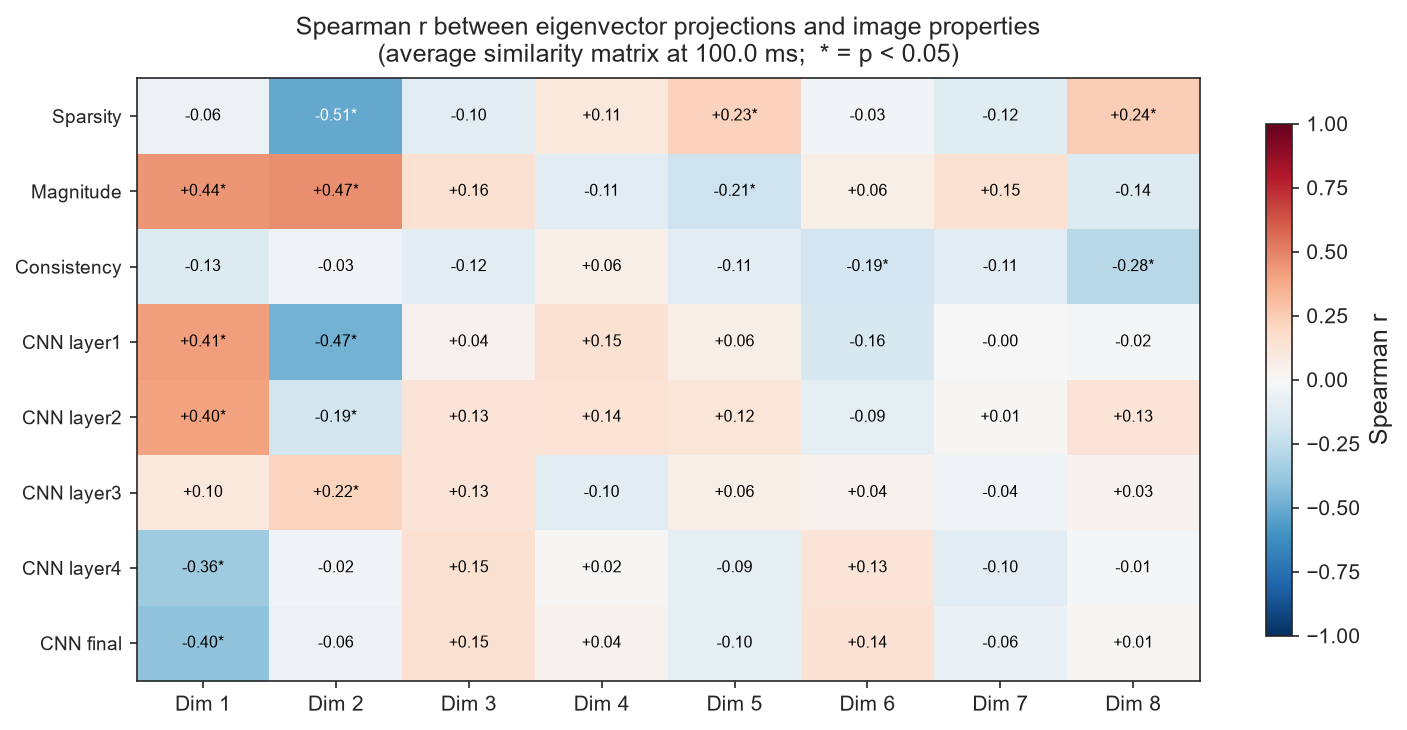

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(eigvec_r, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(N_EIGVECS))
ax.set_xticklabels([f'Dim {k+1}' for k in range(N_EIGVECS)])
ax.set_yticks(range(n_props))
ax.set_yticklabels(prop_names, fontsize=9)
plt.colorbar(im, ax=ax, label='Spearman r', shrink=0.85)
for j in range(n_props):
    for k in range(N_EIGVECS):
        r = eigvec_r[j, k]
        p = eigvec_p[j, k]
        col = 'white' if abs(r) > 0.5 else 'black'
        txt = f'{r:+.2f}{"*" if p < 0.05 else ""}'
        ax.text(k, j, txt, ha='center', va='center', fontsize=7.5, color=col)
ax.set_title(f'Spearman r between eigenvector projections and image properties\n'
             f'(average similarity matrix at {peak_t} ms;  * = p < 0.05)',
             pad=8)

print_figure_data(
    f'Fig. Spearman r between eigenvector projections and image properties (at {peak_t} ms)',
    property_names=prop_names,
    eigenvector_dims=[f'Dim {k+1}' for k in range(N_EIGVECS)],
    spearman_r_matrix=eigvec_r,
    spearman_p_matrix=eigvec_p,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS5_eigenvec_properties.png', bbox_inches='tight')
plt.show()


Fig. S6 — Images at extremes of attractor dimensions (at 100.0 ms)

--- Dim 1 high_image_ids ---
[ 26   5  17 110  48  39]

--- Dim 1 low_image_ids ---
[ 37  62  59  72 111  36]

--- Dim 2 high_image_ids ---
[14 52 18 57 69 61]

--- Dim 2 low_image_ids ---
[11 51 15 77 97 22]

--- Dim 1 high_projection_scores ---
[0.145365 0.141993 0.139797 0.134199 0.133383 0.125909]

--- Dim 1 low_projection_scores ---
[-0.197511 -0.197143 -0.189331 -0.170017 -0.155731 -0.15466 ]

--- Dim 2 high_projection_scores ---
[0.164063 0.158107 0.15242  0.147701 0.125894 0.122755]

--- Dim 2 low_projection_scores ---
[-0.185631 -0.179835 -0.176964 -0.176352 -0.176333 -0.172199]


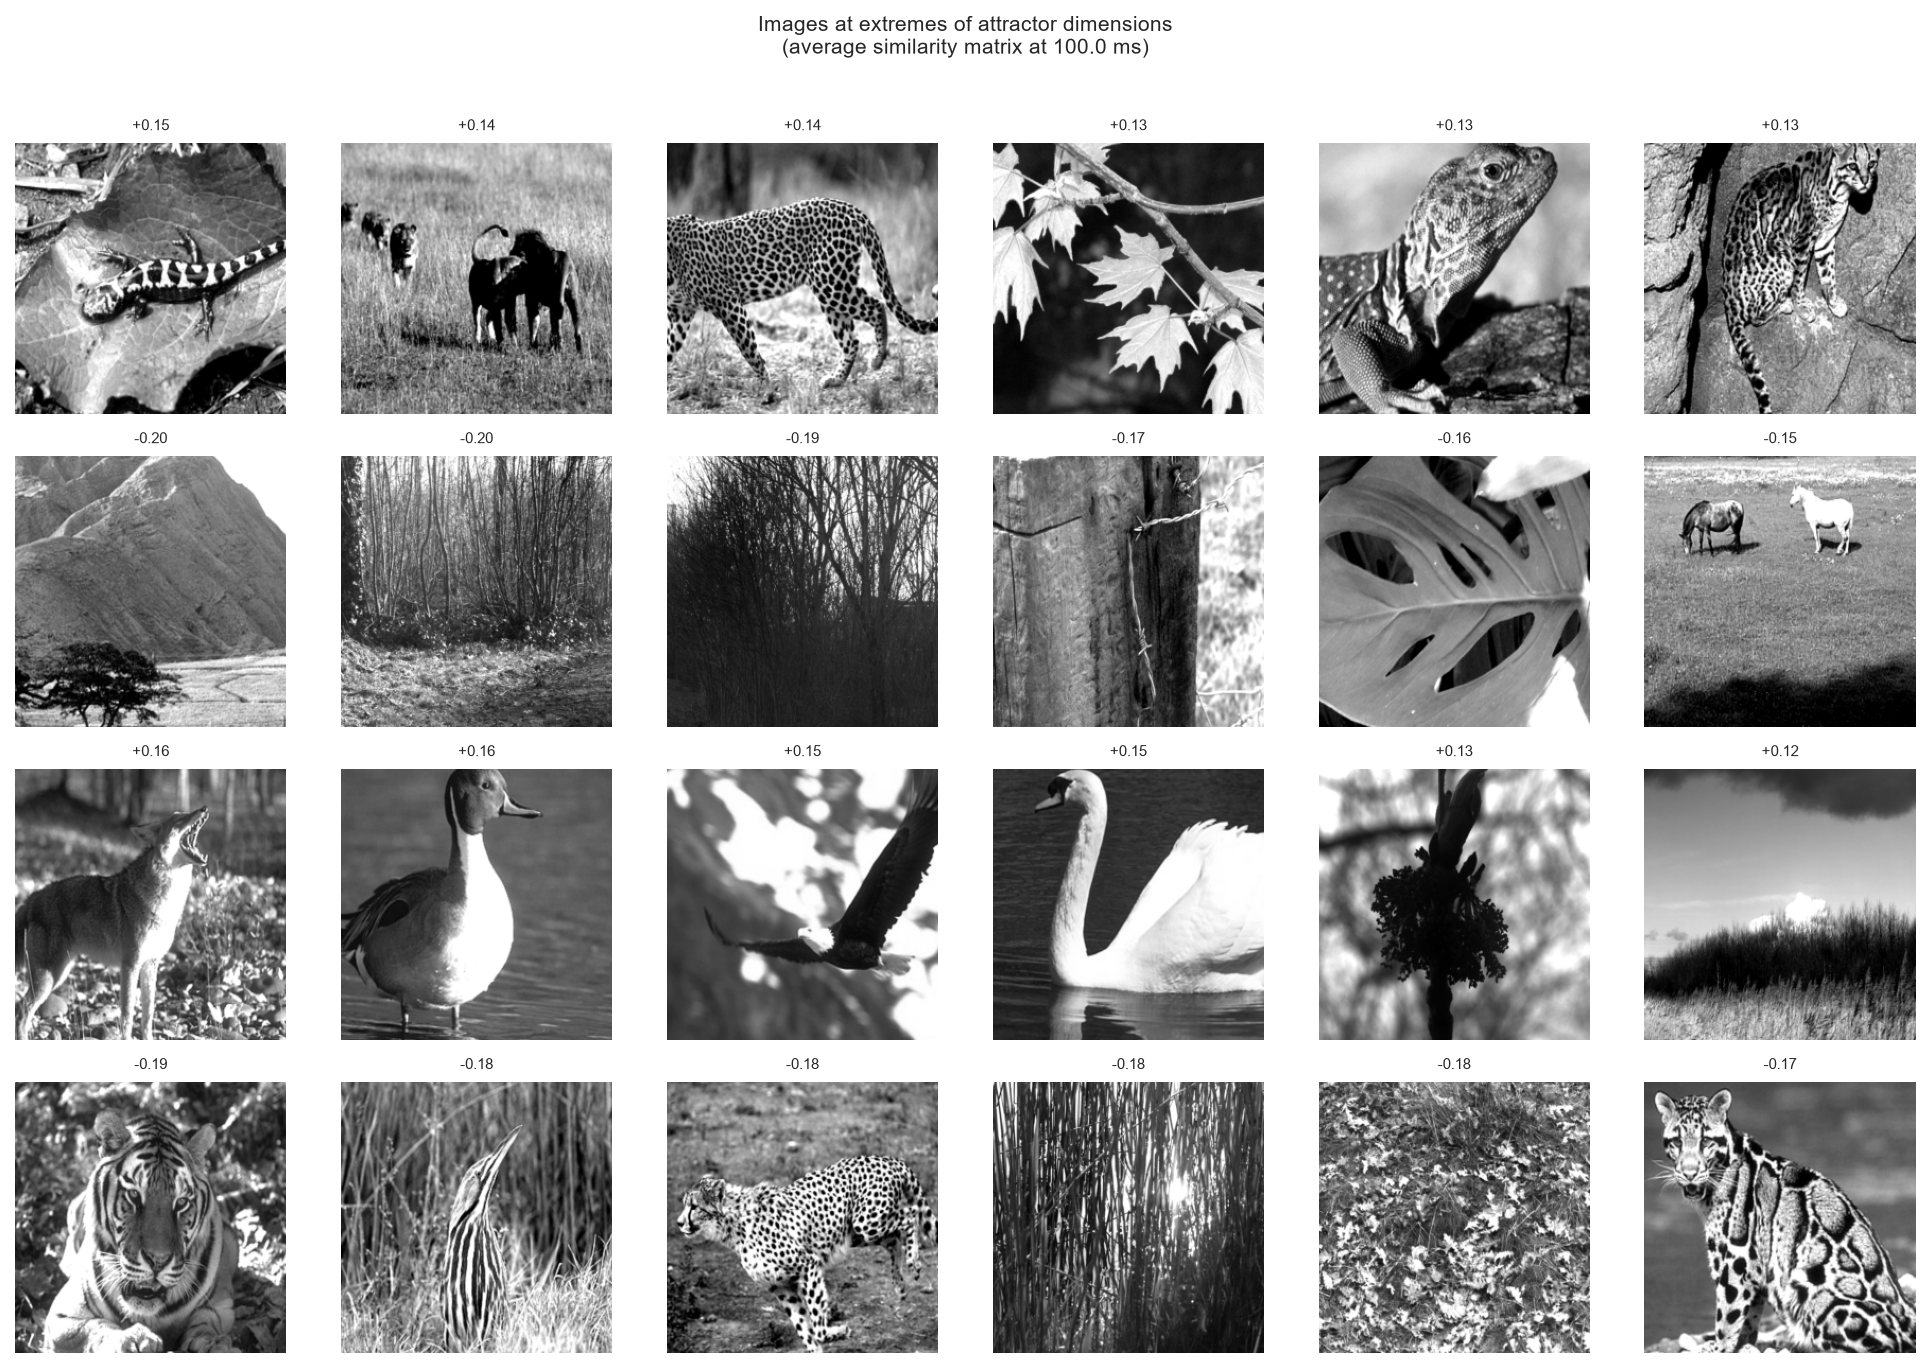

In [9]:
N_EXTREMES = 6
fig, axes = plt.subplots(4, N_EXTREMES, figsize=(2.2 * N_EXTREMES, 9))

gallery_records = []
for dim_idx, dim_label in enumerate(['Dim 1', 'Dim 2']):
    scores  = proj[:, dim_idx]
    top_ids = np.argsort(scores)[-N_EXTREMES:][::-1]
    bot_ids = np.argsort(scores)[:N_EXTREMES]
    for col, img_id in enumerate(top_ids):
        axes[dim_idx*2, col].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
        axes[dim_idx*2, col].set_title(f'{scores[img_id]:+.2f}', fontsize=7)
        axes[dim_idx*2, col].axis('off')
    for col, img_id in enumerate(bot_ids):
        axes[dim_idx*2+1, col].imshow(natural_scenes[img_id], cmap='gray', vmin=0, vmax=255)
        axes[dim_idx*2+1, col].set_title(f'{scores[img_id]:+.2f}', fontsize=7)
        axes[dim_idx*2+1, col].axis('off')
    axes[dim_idx*2,   0].set_ylabel(f'{dim_label}\nhigh', fontsize=9, labelpad=4)
    axes[dim_idx*2+1, 0].set_ylabel(f'{dim_label}\nlow',  fontsize=9, labelpad=4)

    gallery_records.append((f'{dim_label} high', top_ids, scores[top_ids]))
    gallery_records.append((f'{dim_label} low',  bot_ids, scores[bot_ids]))

fig.suptitle(f'Images at extremes of attractor dimensions\n'
             f'(average similarity matrix at {peak_t} ms)',
             y=1.01, fontsize=10)

print_figure_data(
    f'Fig. S6 — Images at extremes of attractor dimensions (at {peak_t} ms)',
    **{f'{row_label}_image_ids': ids for row_label, ids, _ in gallery_records},
    **{f'{row_label}_projection_scores': vals for row_label, _, vals in gallery_records},
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS6_attractor_gallery.png', bbox_inches='tight')
plt.show()